# Pandas Time Series : Analyse climatique de Delhi
Dataset : Daily Climate Time Series (Kaggle)
Date : avril 2026

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\sumanthvrao\daily-climate-time-series-data\versions\3


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os
df = pd.read_csv(os.path.join(path, "DailyDelhiClimateTrain.csv"), index_col = 'date', parse_dates=True )
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [8]:
type(df.index)

pandas.DatetimeIndex

## 2. Plage de dates
On vérifie la date de début, la date de fin et le nombre de jours couverts.

In [11]:
# Plage de dates
# Date de début et date de fin
print("Date de début : ", df.index.min())
print("Date de fin : ", df.index.max())

# Nombre de jours
nb_jours = (df.index.max() - df.index.min()).days
print("Nombre de jours : ", nb_jours)


print("Longueur du dataset : ", len(df))

Date de début :  2013-01-01 00:00:00
Date de fin :  2017-01-01 00:00:00
Nombre de jours :  1461
Longueur du dataset :  1462


## 3. Température moyenne par mois et par année

In [19]:
# Température moyenne par mois et par année
mean_per_m = df['meantemp'].resample('ME').mean()
mean_per_y = df['meantemp'].resample('YE').mean()

In [20]:
mean_per_m.head()

date
2013-01-31    12.074770
2013-02-28    16.867560
2013-03-31    22.814209
2013-04-30    28.895119
2013-05-31    33.776767
Freq: ME, Name: meantemp, dtype: float64

In [21]:
mean_per_y

date
2013-12-31    24.791494
2014-12-31    25.010673
2015-12-31    25.114591
2016-12-31    27.103373
2017-12-31    10.000000
Freq: YE-DEC, Name: meantemp, dtype: float64

La moyenne 2017 (10.0°C) n'est pas représentative : le dataset 
ne contient qu'une seule journée pour cette année (2017-01-01).

## 4. Lissage avec une moyenne mobile (rolling 30 jours)

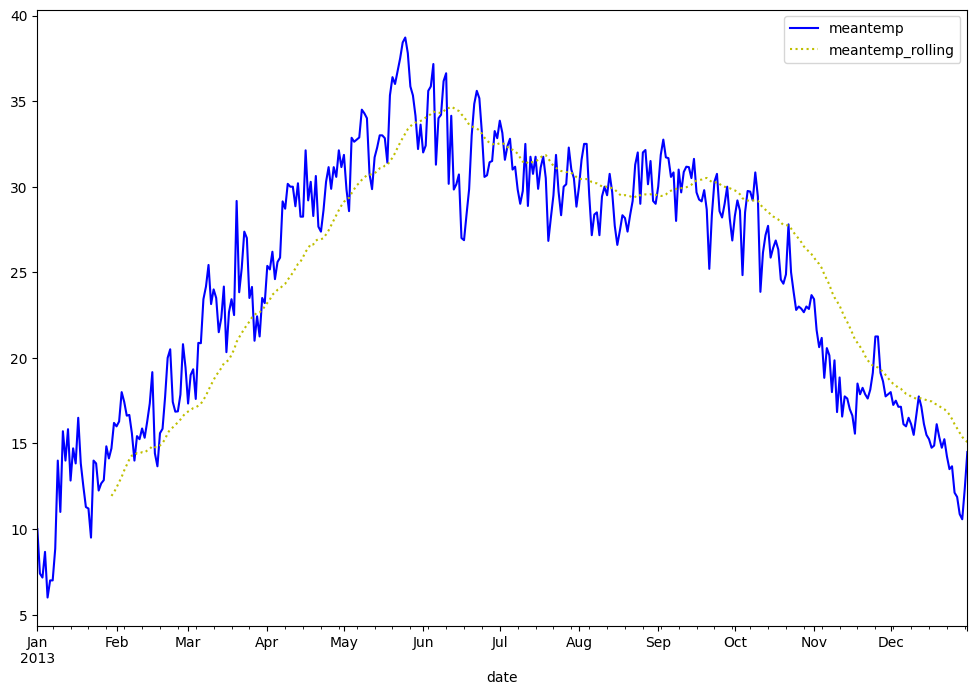

In [29]:
plt.figure(figsize = (12, 8))
df.loc['2013','meantemp'].plot(c = 'b', label = 'meantemp')
df.loc['2013','meantemp'].rolling(window = 30).mean().plot(label = 'meantemp_rolling', c = 'y', ls = ':')
plt.legend()
plt.show()


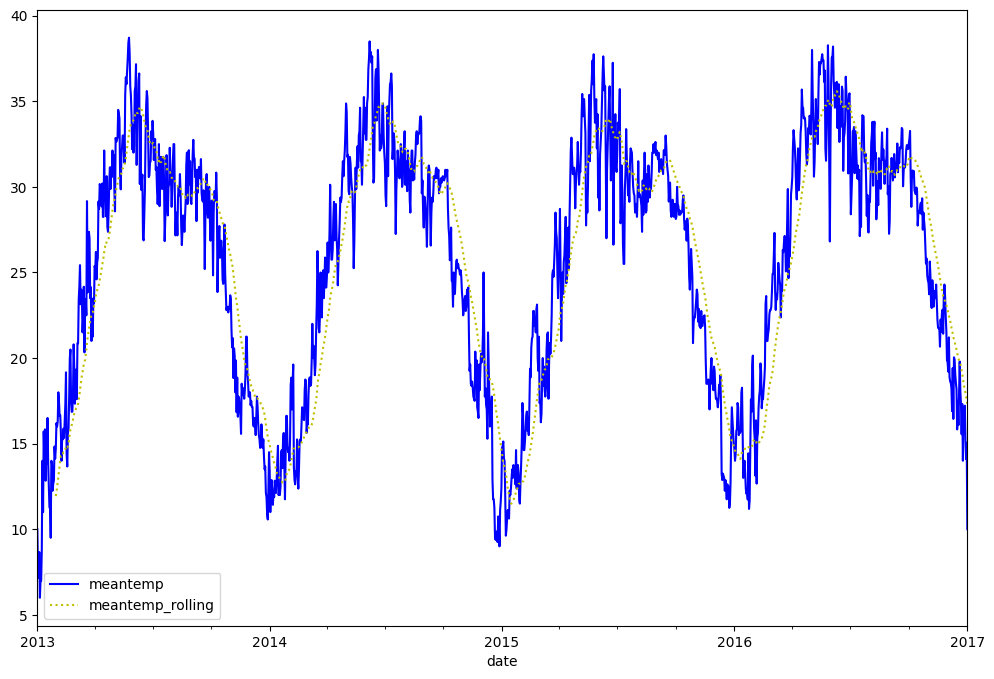

In [31]:
plt.figure(figsize = (12, 8))
df['meantemp'].plot(c = 'b', label = 'meantemp')
df['meantemp'].rolling(window = 30).mean().plot(label = 'meantemp_rolling', c = 'y', ls = ':')
plt.legend()
plt.show()

<Axes: xlabel='date'>

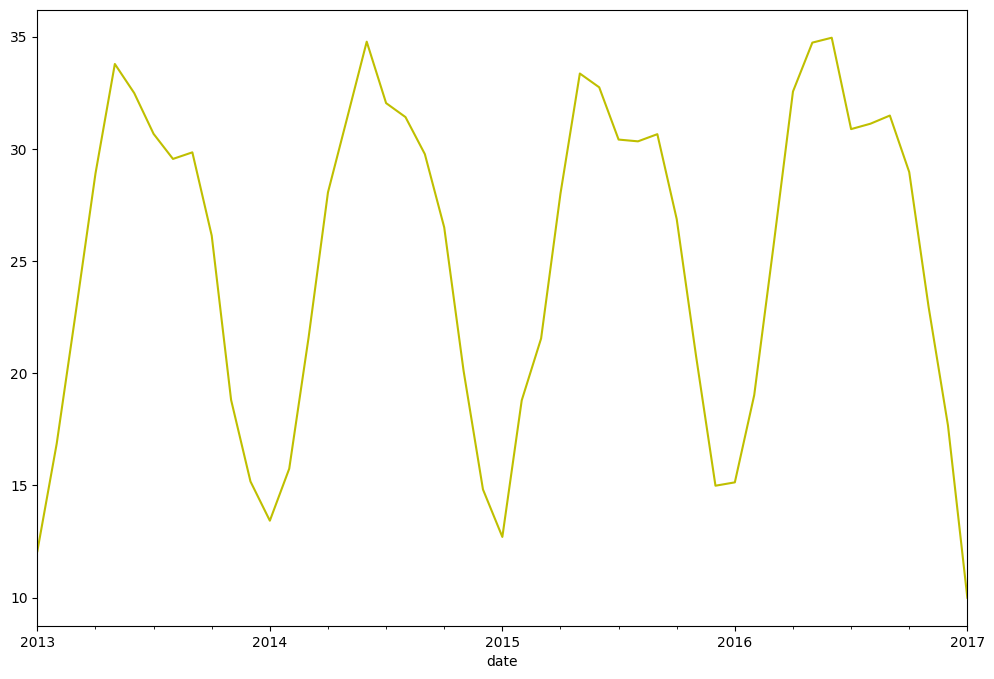

In [35]:
plt.figure(figsize=(12, 8))
mean_per_m.plot(c = 'y', label = 'moyenne_par_mois')

## 5. Température maximale et minimale

In [45]:
# Température maximale et température minimale
print("Mois le plus chaud :", mean_per_m.idxmax())  
print("Mois le plus froid :", mean_per_m.idxmin())  

Mois le plus chaud : 2016-06-30 00:00:00
Mois le plus froid : 2017-01-31 00:00:00


## 6. Plus grande hausse et plus grande baisse de température

In [41]:
df["variation"] = df["meantemp"].diff()
df.head(10)

,meantemp,humidity,wind_speed,meanpressure,variation
date,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,NaN
2013-01-02,7.400000,92.000000,2.980000,1017.800000,-2.600000
2013-01-03,7.166667,87.000000,4.633333,1018.666667,-0.233333
2013-01-04,8.666667,71.333333,1.233333,1017.166667,1.500000
2013-01-05,6.000000,86.833333,3.700000,1016.500000,-2.666667
2013-01-06,7.000000,82.800000,1.480000,1018.000000,1.000000
2013-01-07,7.000000,78.600000,6.300000,1020.000000,0.000000
2013-01-08,8.857143,63.714286,7.142857,1018.714286,1.857143
2013-01-09,14.000000,51.250000,12.500000,1017.000000,5.142857


In [43]:
#Plus grande hausse
jour_hausse = df['variation'].idxmax()
print("Plus grande hausse : ", jour_hausse, " --", df["variation"].max() )

#Plus grande baisse
jour_baisse= df['variation'].idxmin()
print("Plus grande baisse : ", jour_baisse, " --", df["variation"].min() )




Plus grande hausse :  2013-03-20 00:00:00  -- 6.666666666666668
Plus grande baisse :  2015-06-25 00:00:00  -- -10.625


## 7. Moyenne par trimestre

In [44]:
df.resample('3ME').mean()

,meantemp,humidity,wind_speed,meanpressure,variation
date,,,,,
2013-01-31,12.074770,73.028802,4.833913,1017.847734,0.206667
2013-04-30,22.993098,54.298622,8.113949,1011.224826,0.167897
2013-07-31,32.305189,54.140269,8.621571,998.246791,-0.025104
2013-10-31,28.491343,70.586698,5.919966,1004.754658,-0.056159
2014-01-31,15.774974,76.764079,4.940340,1016.820523,-0.096920
2014-04-30,21.933186,58.485152,7.484992,1012.010433,0.207865
2014-07-31,32.714734,49.157666,8.723880,999.538448,-0.008152
2014-10-31,29.217814,61.276870,6.553351,1005.486410,-0.099185
2015-01-31,15.832880,67.959433,4.185287,1016.462668,-0.104620
